# Approach B: Siamese BiLSTM + CharCNN with Stylometric Features
## Authorship Verification — COMP34812 Coursework

**Task:** Given two text sequences, predict whether they were written by the same author (1) or different authors (0).

**Approach Category:** B — Deep learning without transformer architectures.

**Architecture Overview:**
1. **Stylometric feature extraction** — 29 handcrafted features capturing writing style
2. **Siamese BiLSTM with multi-head attention** — shared-weight BiLSTM encodes both texts using GloVe embeddings
3. **Character-level CNN** — captures punctuation, capitalisation, and spelling patterns
4. **Comparison network** — element-wise difference, product, and concatenation of both representations
5. **Classification head** — FC layers with residual connections → binary prediction

**Key improvements in this version:**
- Character CNN branch for authorship-specific signals
- Spatial dropout + higher regularisation to combat overfitting
- Label smoothing + swap augmentation
- Gradient accumulation for larger effective batch size
- Multi-head attention pooling
- Layer normalisation + residual connections


## 1. Setup & Installation


In [ ]:
import os
import random
import re
import string
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import sent_tokenize
from collections import Counter
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")


Using device: cuda


## 2. Configuration

All hyperparameters in one place. Tweak these to experiment.


In [ ]:
# ============================================================
# HYPERPARAMETERS
# ============================================================

# --- Data ---
MAX_LEN = 200          # Word-level token limit (data maxes at ~180 words)
BATCH_SIZE = 64
ACCUM_STEPS = 2        # Gradient accumulation → effective batch = 128

# --- GloVe ---
EMBED_DIM = 300        # GloVe dimension
MAX_VOCAB = 50000      # Top N words to keep

# --- BiLSTM ---
HIDDEN_DIM = 128             # was 150 — slightly smaller, less overfitting
NUM_LAYERS = 2               # same
DROPOUT = 0.25               # was 0.4 — way too high before
EMBED_DROPOUT = 0.15         # was 0.3
SPATIAL_DROPOUT_P = 0.1

# --- Character CNN ---
CHAR_VOCAB_SIZE = 128  # ASCII
CHAR_EMBED_DIM = 30
CHAR_CNN_FILTERS = 64
CHAR_MAX_LEN = 800

# --- Training ---
LEARNING_RATE = 2e-3         # was 8e-4 — this is the biggest change
WEIGHT_DECAY = 1e-4          # was 5e-4
LABEL_SMOOTHING = 0.02       # was 0.05
ACCUM_STEPS = 1              # was 2 — simpler, faster
NUM_EPOCHS = 20              # was 25
PATIENCE = 5                 # was 7 — stop sooner if stuck

# --- Special tokens ---
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

print("Configuration set!")
print(f"  Effective batch size: {BATCH_SIZE * ACCUM_STEPS}")
print(f"  MAX_LEN: {MAX_LEN} word tokens")
print(f"  CHAR_MAX_LEN: {CHAR_MAX_LEN} characters")


Configuration set!
  Effective batch size: 64
  MAX_LEN: 200 word tokens
  CHAR_MAX_LEN: 800 characters


## 3. Data Loading & Exploration


In [ ]:
# --- Update these paths for your environment ---
TRAIN_PATH = 'train.csv'
DEV_PATH = 'dev.csv'

train_df = pd.read_csv(TRAIN_PATH)
dev_df = pd.read_csv(DEV_PATH)

train_df['label'] = train_df['label'].astype(int)
dev_df['label'] = dev_df['label'].astype(int)

print(f"Training set: {train_df.shape[0]} pairs")
print(f"Dev set:      {dev_df.shape[0]} pairs")
print(f"\nTraining label distribution:\n{train_df['label'].value_counts()}")
print(f"\nDev label distribution:\n{dev_df['label'].value_counts()}")

# Check for missing values
print(f"\nMissing values in train: {train_df[['text_1','text_2','label']].isnull().sum().sum()}")
print(f"Missing values in dev:   {dev_df[['text_1','text_2','label']].isnull().sum().sum()}")

# Fill any NaN text with empty string
train_df['text_1'] = train_df['text_1'].fillna('')
train_df['text_2'] = train_df['text_2'].fillna('')
dev_df['text_1'] = dev_df['text_1'].fillna('')
dev_df['text_2'] = dev_df['text_2'].fillna('')


Training set: 27643 pairs
Dev set:      5993 pairs

Training label distribution:
label
0    13950
1    13693
Name: count, dtype: int64

Dev label distribution:
label
1    3056
0    2937
Name: count, dtype: int64

Missing values in train: 0
Missing values in dev:   0


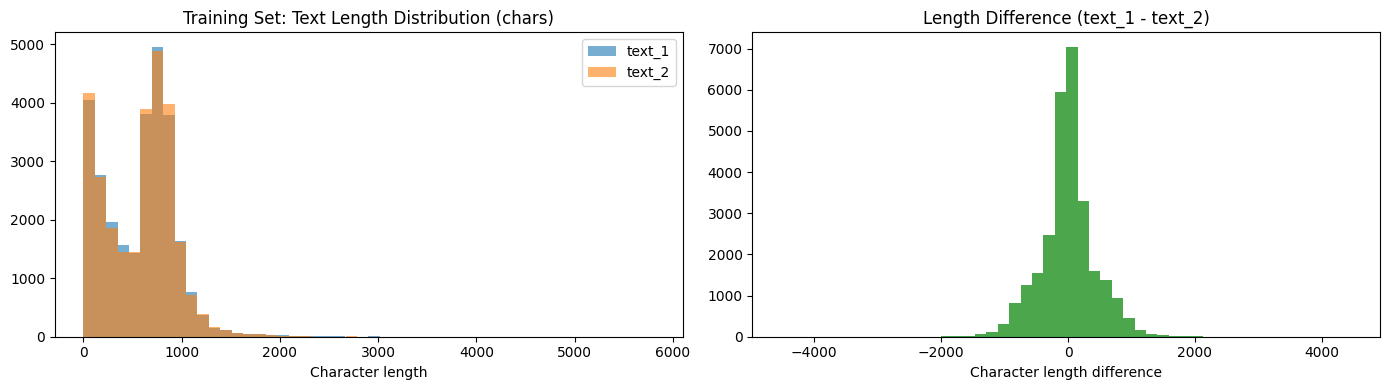

In [ ]:
# --- Text length analysis ---
train_df['len_1'] = train_df['text_1'].str.len()
train_df['len_2'] = train_df['text_2'].str.len()
dev_df['len_1'] = dev_df['text_1'].str.len()
dev_df['len_2'] = dev_df['text_2'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(train_df['len_1'], bins=50, alpha=0.6, label='text_1')
axes[0].hist(train_df['len_2'], bins=50, alpha=0.6, label='text_2')
axes[0].set_title('Training Set: Text Length Distribution (chars)')
axes[0].set_xlabel('Character length')
axes[0].legend()

axes[1].hist(train_df['len_1'] - train_df['len_2'], bins=50, alpha=0.7, color='green')
axes[1].set_title('Length Difference (text_1 - text_2)')
axes[1].set_xlabel('Character length difference')
plt.tight_layout()
plt.show()


## 4. Stylometric Feature Extraction

**Why stylometric features?**

Authorship verification is about *how* someone writes, not *what* they write. We extract 29 handcrafted features per text capturing:
- **Lexical:** word length stats, vocabulary richness, proportion of long/short words
- **Punctuation:** frequency of commas, periods, exclamation marks, etc.
- **Structural:** sentence length, sentence count
- **Character-level:** digit ratio, uppercase ratio, whitespace ratio
- **Function words:** stopword proportion (strong authorship signal)
- **Special:** URL count, emoticon rate, contraction rate

We compute the **absolute difference** between each pair to capture stylistic (dis)similarity.


In [ ]:
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words('english'))

def extract_stylometric_features(text):
    """Extract a vector of stylometric features from a single text."""
    features = {}

    if not isinstance(text, str) or len(text.strip()) == 0:
        return {f: 0.0 for f in _get_feature_names()}

    chars = list(text)
    words = text.split()
    num_chars = max(len(text), 1)
    num_words = max(len(words), 1)

    # --- Lexical features ---
    word_lengths = [len(w) for w in words]
    features['avg_word_length'] = np.mean(word_lengths)
    features['std_word_length'] = np.std(word_lengths) if len(word_lengths) > 1 else 0.0
    features['max_word_length'] = max(word_lengths) if word_lengths else 0.0
    features['type_token_ratio'] = len(set(w.lower() for w in words)) / num_words
    features['long_word_ratio'] = sum(1 for w in words if len(w) > 6) / num_words
    features['short_word_ratio'] = sum(1 for w in words if len(w) <= 3) / num_words

    # --- Punctuation features ---
    features['comma_rate'] = text.count(',') / num_words
    features['period_rate'] = text.count('.') / num_words
    features['exclamation_rate'] = text.count('!') / num_words
    features['question_rate'] = text.count('?') / num_words
    features['colon_rate'] = text.count(':') / num_words
    features['semicolon_rate'] = text.count(';') / num_words
    features['ellipsis_rate'] = text.count('...') / num_words
    features['dash_rate'] = (text.count('-') + text.count('\u2014')) / num_words
    features['quote_rate'] = (text.count('"') + text.count("'")) / num_words
    features['paren_rate'] = (text.count('(') + text.count(')')) / num_words
    punct_count = sum(1 for c in text if c in string.punctuation)
    features['punct_density'] = punct_count / num_chars

    # --- Structural features ---
    try:
        sentences = sent_tokenize(text)
    except:
        sentences = text.split('.')
    num_sentences = max(len(sentences), 1)
    sent_lengths = [len(s.split()) for s in sentences]
    features['avg_sentence_length'] = np.mean(sent_lengths)
    features['std_sentence_length'] = np.std(sent_lengths) if len(sent_lengths) > 1 else 0.0
    features['num_sentences'] = num_sentences
    features['words_per_text'] = num_words

    # --- Character-level features ---
    features['uppercase_ratio'] = sum(1 for c in text if c.isupper()) / num_chars
    features['digit_ratio'] = sum(1 for c in text if c.isdigit()) / num_chars
    features['whitespace_ratio'] = sum(1 for c in text if c.isspace()) / num_chars

    # --- Function word / special features ---
    lower_words = [w.lower() for w in words]
    features['stopword_ratio'] = sum(1 for w in lower_words if w in STOPWORDS) / num_words
    features['url_count'] = len(re.findall(r'http[s]?://\S+|urlLink', text)) / num_words
    features['emoji_like_rate'] = len(re.findall(r'[:;][\-]?[)(DPp/\\|]', text)) / num_words
    features['contraction_rate'] = len(re.findall(r"\w+'\w+", text)) / num_words
    features['capitalized_word_ratio'] = sum(1 for w in words if w[0].isupper() and len(w) > 1) / num_words

    return features


def _get_feature_names():
    dummy = extract_stylometric_features("Hello world, this is a test.")
    return list(dummy.keys())


# Test on a sample
sample_text = train_df.iloc[0]['text_1']
feats = extract_stylometric_features(sample_text)
print(f"Extracted {len(feats)} features from sample text")
print(f"Sample: {sample_text[:100]}...")


Extracted 29 features from sample text
Sample: halloween with kids is fun - getting them to bed - not so much. :)...


In [ ]:
def compute_pair_stylometric_features(df):
    """Extract stylometric features for each pair, return absolute differences."""
    feature_names = _get_feature_names()
    all_diffs = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extracting stylometric features"):
        f1 = extract_stylometric_features(row['text_1'])
        f2 = extract_stylometric_features(row['text_2'])
        diff = [abs(f1[k] - f2[k]) for k in feature_names]
        all_diffs.append(diff)

    return np.array(all_diffs, dtype=np.float32), feature_names

print("Processing training set...")
train_style_feats, feat_names = compute_pair_stylometric_features(train_df)
print("Processing dev set...")
dev_style_feats, _ = compute_pair_stylometric_features(dev_df)

print(f"\nStylometric feature shapes: Train {train_style_feats.shape}, Dev {dev_style_feats.shape}")


Processing training set...


Extracting stylometric features:   0%|          | 0/27643 [00:00<?, ?it/s]

Processing dev set...


Extracting stylometric features:   0%|          | 0/5993 [00:00<?, ?it/s]


Stylometric feature shapes: Train (27643, 29), Dev (5993, 29)


In [ ]:
# --- Normalise stylometric features ---
style_scaler = StandardScaler()
train_style_feats = style_scaler.fit_transform(train_style_feats)
dev_style_feats = style_scaler.transform(dev_style_feats)

STYLE_DIM = train_style_feats.shape[1]
print(f"Stylometric features normalised. Dimension: {STYLE_DIM}")


Stylometric features normalised. Dimension: 29


## 5. GloVe Embeddings & Vocabulary

We use **GloVe 6B 100d** — pre-trained word vectors (not transformer-based, so allowed for Category B). We build a vocabulary from training data and create an embedding matrix.


In [ ]:
# --- Download GloVe ---
import urllib.request
import zipfile

GLOVE_DIR = 'glove'
GLOVE_PATH = os.path.join(GLOVE_DIR, 'glove.6B.300d.txt')

if not os.path.exists(GLOVE_PATH):
    os.makedirs(GLOVE_DIR, exist_ok=True)
    print("Downloading GloVe embeddings (~350MB, may take a few minutes)...")
    url = "https://nlp.stanford.edu/data/glove.6B.zip"
    zip_path = os.path.join(GLOVE_DIR, "glove.6B.zip")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extract('glove.6B.300d.txt', GLOVE_DIR)
    os.remove(zip_path)
    print("Done!")
else:
    print("GloVe embeddings already downloaded.")


Done!


In [ ]:
# --- Tokenizer ---
def simple_tokenize(text):
    """Lowercase and split into words + punctuation tokens."""
    text = text.lower().strip()
    return re.findall(r"\w+|[^\w\s]", text)

# --- Build vocabulary ---
print("Building vocabulary...")
word_counts = Counter()
for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    word_counts.update(simple_tokenize(row['text_1']))
    word_counts.update(simple_tokenize(row['text_2']))

vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word, _ in word_counts.most_common(MAX_VOCAB - 2):
    vocab[word] = len(vocab)

print(f"Vocabulary size: {len(vocab)}")
coverage = sum(word_counts[w] for w in list(vocab.keys())[2:]) / sum(word_counts.values())
print(f"Coverage: {coverage:.2%}")


Building vocabulary...


  0%|          | 0/27643 [00:00<?, ?it/s]

Vocabulary size: 50000
Coverage: 99.29%


In [ ]:
# --- Load GloVe vectors into embedding matrix ---
def load_glove(path, vocab, embed_dim):
    embedding_matrix = np.random.normal(0, 0.1, (len(vocab), embed_dim)).astype(np.float32)
    embedding_matrix[0] = 0  # PAD = zeros

    found = 0
    with open(path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc="Loading GloVe"):
            parts = line.rstrip().split(' ')
            word = parts[0]
            if word in vocab:
                embedding_matrix[vocab[word]] = np.array(parts[1:], dtype=np.float32)
                found += 1

    print(f"Found GloVe vectors for {found}/{len(vocab)} words ({found/len(vocab):.2%})")
    return embedding_matrix

embedding_matrix = load_glove(GLOVE_PATH, vocab, EMBED_DIM)
print(f"Embedding matrix shape: {embedding_matrix.shape}")


Loading GloVe: 0it [00:00, ?it/s]

Found GloVe vectors for 41940/50000 words (83.88%)
Embedding matrix shape: (50000, 300)


In [ ]:
def text_to_indices(text, vocab, max_len):
    """Convert text to padded list of word indices."""
    tokens = simple_tokenize(text)[:max_len]
    indices = [vocab.get(t, vocab[UNK_TOKEN]) for t in tokens]
    indices += [vocab[PAD_TOKEN]] * (max_len - len(indices))
    return indices


## 6. Dataset & DataLoader

Includes character-level inputs, swap augmentation, and label smoothing.


In [ ]:
class AuthorshipDataset(Dataset):
    def __init__(self, df, style_features, vocab, max_len,
                 char_max_len=800, augment=False):
        self.df = df.reset_index(drop=True)
        self.style_features = style_features
        self.vocab = vocab
        self.max_len = max_len
        self.char_max_len = char_max_len
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def text_to_char_indices(self, text):
        chars = [min(ord(c), CHAR_VOCAB_SIZE - 1) for c in text[:self.char_max_len]]
        chars += [0] * (self.char_max_len - len(chars))
        return chars

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        t1, t2 = row['text_1'], row['text_2']

        # Swap augmentation during training
        if self.augment and random.random() < 0.5:
            t1, t2 = t2, t1

        text1_ids = text_to_indices(t1, self.vocab, self.max_len)
        text2_ids = text_to_indices(t2, self.vocab, self.max_len)
        char1_ids = self.text_to_char_indices(t1)
        char2_ids = self.text_to_char_indices(t2)
        style = self.style_features[idx]
        label = float(row['label'])

        # Label smoothing during training
        if self.augment:
            label = label * (1 - LABEL_SMOOTHING) + (1 - label) * LABEL_SMOOTHING

        return {
            'text1': torch.tensor(text1_ids, dtype=torch.long),
            'text2': torch.tensor(text2_ids, dtype=torch.long),
            'char1': torch.tensor(char1_ids, dtype=torch.long),
            'char2': torch.tensor(char2_ids, dtype=torch.long),
            'style': torch.tensor(style, dtype=torch.float32),
            'label': torch.tensor(label, dtype=torch.float32),
        }

# --- Create datasets and loaders ---
train_dataset = AuthorshipDataset(train_df, train_style_feats, vocab, MAX_LEN,
                                   char_max_len=CHAR_MAX_LEN, augment=True)
dev_dataset = AuthorshipDataset(dev_df, dev_style_feats, vocab, MAX_LEN,
                                 char_max_len=CHAR_MAX_LEN, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=0, pin_memory=True)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)

# Sanity check
batch = next(iter(train_loader))
print("Batch shapes:")
for k, v in batch.items():
    print(f"  {k}: {v.shape}")


Batch shapes:
  text1: torch.Size([64, 200])
  text2: torch.Size([64, 200])
  char1: torch.Size([64, 800])
  char2: torch.Size([64, 800])
  style: torch.Size([64, 29])
  label: torch.Size([64])


## 7. Model Architecture

### Components:
1. **CharCNN** — Multiple 1D convolution filters (sizes 3,4,5,7) over character embeddings, capturing character n-gram patterns like punctuation habits and spelling
2. **SpatialDropout1D** — Drops entire embedding channels (better than random dropout for sequences)
3. **AttentionPool** — Multi-head attention pooling over BiLSTM hidden states
4. **SiameseBiLSTM** — Shared-weight encoder with all components combined


In [ ]:
class CharCNN(nn.Module):
    """Character-level CNN — captures punctuation, capitalisation, spelling patterns."""
    def __init__(self, char_vocab_size=128, char_embed_dim=30,
                 num_filters=64, filter_sizes=(3, 4, 5, 7)):
        super().__init__()
        self.char_embedding = nn.Embedding(char_vocab_size, char_embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(char_embed_dim, num_filters, kernel_size=fs, padding=fs // 2)
            for fs in filter_sizes
        ])
        self.output_dim = num_filters * len(filter_sizes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, char_ids):
        embedded = self.char_embedding(char_ids).transpose(1, 2)
        conv_outputs = []
        for conv in self.convs:
            c = F.relu(conv(embedded))
            c = F.max_pool1d(c, c.size(2)).squeeze(2)
            conv_outputs.append(c)
        return self.dropout(torch.cat(conv_outputs, dim=1))


class SpatialDropout1D(nn.Module):
    """Drops entire embedding channels instead of random positions."""
    def __init__(self, p=0.2):
        super().__init__()
        self.p = p

    def forward(self, x):
        if not self.training:
            return x
        mask = torch.bernoulli(
            torch.ones(x.size(0), 1, x.size(2), device=x.device) * (1 - self.p)
        )
        return x * mask / (1 - self.p)


class AttentionPool(nn.Module):
    """Multi-head attention pooling over sequence of hidden states."""
    def __init__(self, hidden_dim, num_heads=4):
        super().__init__()
        self.heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // num_heads),
                nn.Tanh(),
                nn.Linear(hidden_dim // num_heads, 1)
            ) for _ in range(num_heads)
        ])

    def forward(self, hidden_states, mask=None):
        head_outputs = []
        for head in self.heads:
            scores = head(hidden_states).squeeze(-1)
            if mask is not None:
                scores = scores.masked_fill(mask == 0, float('-inf'))
            weights = F.softmax(scores, dim=1)
            pooled = torch.bmm(weights.unsqueeze(1), hidden_states).squeeze(1)
            head_outputs.append(pooled)
        return torch.stack(head_outputs, dim=0).mean(dim=0)


class SiameseBiLSTM(nn.Module):
    """
    Siamese BiLSTM + CharCNN with attention for Authorship Verification.

    Both texts pass through the SAME encoder (shared weights).
    Comparison via |diff|, product, concatenation of word + char representations.
    Stylometric features concatenated before classification.
    """
    def __init__(self, embedding_matrix, hidden_dim=150, num_layers=2,
                 style_feat_dim=29, dropout=0.4):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape

        # Word embedding (GloVe initialised)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix))
        self.spatial_dropout = SpatialDropout1D(SPATIAL_DROPOUT_P)
        self.embed_dropout = nn.Dropout(EMBED_DROPOUT)

        # Character CNN (shared for both texts)
        self.char_cnn = CharCNN(CHAR_VOCAB_SIZE, CHAR_EMBED_DIM, CHAR_CNN_FILTERS)
        char_out = self.char_cnn.output_dim  # 64 * 4 = 256

        # BiLSTM (shared)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0)
        lstm_out_dim = hidden_dim * 2

        # Multi-head attention pooling
        self.attention = AttentionPool(lstm_out_dim, num_heads=4)

        # Classifier dimensions:
        # word: |w1-w2| + w1*w2 + w1 + w2 = 4 * lstm_out_dim
        # char: |c1-c2| + c1*c2 = 2 * char_out
        # style features
        comparison_dim = lstm_out_dim * 4 + char_out * 2 + style_feat_dim

        self.fc1 = nn.Linear(comparison_dim, 256)
        self.ln1 = nn.LayerNorm(256)
        self.fc2 = nn.Linear(256, 128)
        self.ln2 = nn.LayerNorm(128)
        self.fc3 = nn.Linear(128, 128)
        self.ln3 = nn.LayerNorm(128)
        self.fc_out = nn.Linear(128, 1)
        self.dropout = nn.Dropout(dropout)

    def encode_words(self, token_ids):
        mask = (token_ids != 0).float()
        embedded = self.embedding(token_ids)
        embedded = self.spatial_dropout(embedded)
        embedded = self.embed_dropout(embedded)
        lstm_out, _ = self.lstm(embedded)
        return self.attention(lstm_out, mask)

    def encode_chars(self, char_ids):
        return self.char_cnn(char_ids)

    def forward(self, text1_ids, text2_ids, char1_ids, char2_ids, style_feats):
        # Encode both texts with shared weights
        w1 = self.encode_words(text1_ids)
        w2 = self.encode_words(text2_ids)
        c1 = self.encode_chars(char1_ids)
        c2 = self.encode_chars(char2_ids)

        # Comparison
        combined = torch.cat([
            torch.abs(w1 - w2), w1 * w2, w1, w2,     # word-level
            torch.abs(c1 - c2), c1 * c2,               # char-level
            style_feats                                  # stylometric
        ], dim=1)

        # Classifier with residual connection
        x = F.relu(self.ln1(self.fc1(combined)))
        x = self.dropout(x)
        x = F.relu(self.ln2(self.fc2(x)))
        x = self.dropout(x)
        residual = x
        x = F.relu(self.ln3(self.fc3(x)))
        x = self.dropout(x)
        x = x + residual
        return self.fc_out(x).squeeze(-1)


In [ ]:
# --- Instantiate model ---
model = SiameseBiLSTM(
    embedding_matrix=embedding_matrix,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    style_feat_dim=STYLE_DIM,
    dropout=DROPOUT,
).to(DEVICE)

model.embedding.weight.requires_grad = False
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Total parameters:     16,393,669
Trainable parameters: 1,393,669


## 8. Training Loop

Uses gradient accumulation (effective batch size 128), gradient clipping, and cosine annealing LR schedule. Monitors dev F1 for early stopping.


In [ ]:
def train_epoch(model, loader, optimizer, criterion, device,
                accum_steps=2, max_grad_norm=1.0):
    model.train()
    total_loss = 0
    num_batches = 0
    optimizer.zero_grad()

    for i, batch in enumerate(tqdm(loader, desc="Training", leave=False)):
        text1 = batch['text1'].to(device)
        text2 = batch['text2'].to(device)
        char1 = batch['char1'].to(device)
        char2 = batch['char2'].to(device)
        style = batch['style'].to(device)
        labels = batch['label'].to(device)

        logits = model(text1, text2, char1, char2, style)
        loss = criterion(logits, labels) / accum_steps
        loss.backward()

        if (i + 1) % accum_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()
            optimizer.zero_grad()

        total_loss += loss.item() * accum_steps
        num_batches += 1

    # Flush remaining gradients
    if num_batches % accum_steps != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        optimizer.zero_grad()

    return total_loss / num_batches


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    num_batches = 0
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            text1 = batch['text1'].to(device)
            text2 = batch['text2'].to(device)
            char1 = batch['char1'].to(device)
            char2 = batch['char2'].to(device)
            style = batch['style'].to(device)
            labels = batch['label'].to(device)

            logits = model(text1, text2, char1, char2, style)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()

            total_loss += loss.item()
            num_batches += 1
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().round().numpy().astype(int))

    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)
    return total_loss / num_batches, f1, acc, all_preds, all_probs, all_labels


In [ ]:
# --- Training ---
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

best_f1 = 0
patience_counter = 0
history = {'train_loss': [], 'dev_loss': [], 'dev_f1': [], 'dev_acc': []}

print(f"Training for up to {NUM_EPOCHS} epochs (patience={PATIENCE})...\n")

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE,
                              accum_steps=ACCUM_STEPS)
    dev_loss, dev_f1, dev_acc, dev_preds, dev_probs, dev_labels = evaluate(
        model, dev_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['dev_loss'].append(dev_loss)
    history['dev_f1'].append(dev_f1)
    history['dev_acc'].append(dev_acc)

    lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"Train: {train_loss:.4f} | "
          f"Dev: {dev_loss:.4f} | "
          f"F1: {dev_f1:.4f} | "
          f"Acc: {dev_acc:.4f} | "
          f"LR: {lr:.6f}")

    if dev_f1 > best_f1:
        best_f1 = dev_f1
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'dev_f1': dev_f1,
            'dev_acc': dev_acc,
            'vocab': vocab,
            'style_scaler': style_scaler,
            'config': {
                'hidden_dim': HIDDEN_DIM,
                'num_layers': NUM_LAYERS,
                'style_dim': STYLE_DIM,
                'dropout': DROPOUT,
                'max_len': MAX_LEN,
                'char_max_len': CHAR_MAX_LEN,
                'embed_dim': EMBED_DIM,
                'max_vocab': MAX_VOCAB,
            }
        }, 'best_siamese_bilstm_v2.pt')
        print(f"  → New best! (F1: {dev_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

print(f"\nBest Dev F1: {best_f1:.4f}")


Training for up to 20 epochs (patience=5)...



Training:   0%|          | 0/432 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch  1/20 | Train: 0.6952 | Dev: 0.6608 | F1: 0.6005 | Acc: 0.6005 | LR: 0.001988
  → New best! (F1: 0.6005)


Training:   0%|          | 0/432 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch 19/20 | Train: 0.2290 | Dev: 0.6170 | F1: 0.7584 | Acc: 0.7584 | LR: 0.000012


Training:   0%|          | 0/432 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch 20/20 | Train: 0.2236 | Dev: 0.6214 | F1: 0.7597 | Acc: 0.7597 | LR: 0.000000

Best Dev F1: 0.7597


## 9. Evaluation on Dev Set


In [ ]:
# --- Load best model ---
checkpoint = torch.load('best_siamese_bilstm_v2.pt', map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']} (F1: {checkpoint['dev_f1']:.4f})")

# --- Evaluate ---
_, dev_f1, dev_acc, dev_preds, dev_probs, dev_labels = evaluate(
    model, dev_loader, criterion, DEVICE)

print(f"\n{'='*50}")
print(f"DEV SET RESULTS")
print(f"{'='*50}")
print(f"Macro F1:  {dev_f1:.4f}")
print(f"Accuracy:  {dev_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(dev_labels, dev_preds,
                            target_names=['Different Author (0)', 'Same Author (1)']))


Loaded best model from epoch 16 (F1: 0.7597)


Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]


DEV SET RESULTS
Macro F1:  0.7597
Accuracy:  0.7597

Classification Report:
                      precision    recall  f1-score   support

Different Author (0)       0.75      0.77      0.76      2937
     Same Author (1)       0.77      0.75      0.76      3056

            accuracy                           0.76      5993
           macro avg       0.76      0.76      0.76      5993
        weighted avg       0.76      0.76      0.76      5993



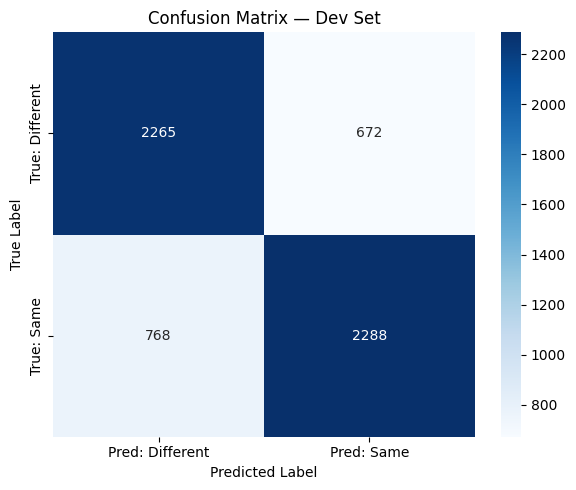

In [ ]:
# --- Confusion Matrix ---
cm = confusion_matrix(dev_labels, dev_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Different', 'Pred: Same'],
            yticklabels=['True: Different', 'True: Same'], ax=ax)
ax.set_title('Confusion Matrix — Dev Set')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()


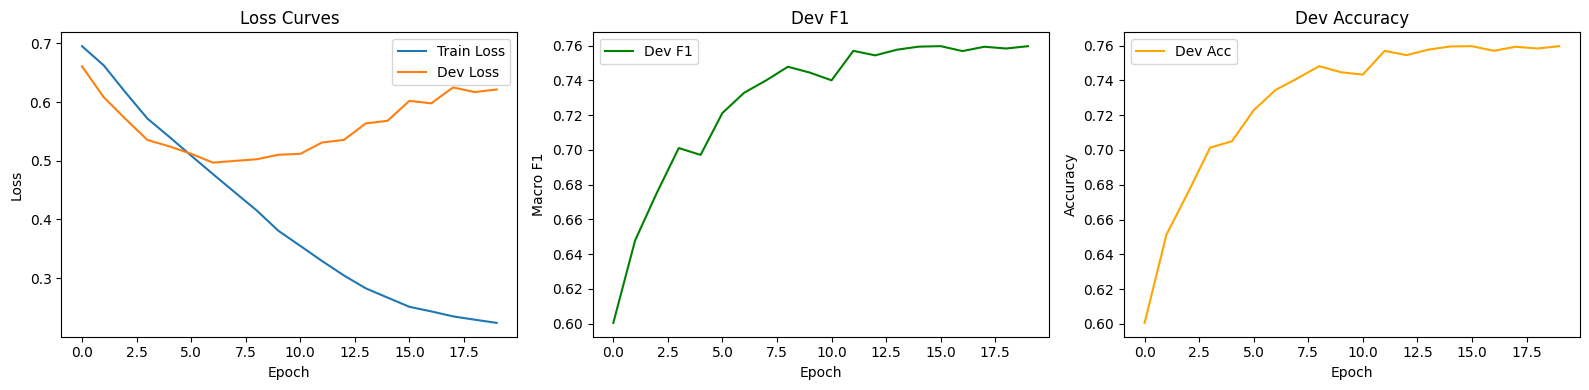

Overfitting check:
  Best train loss: 0.2236
  Corresponding dev loss: 0.6214


In [ ]:
# --- Training curves ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['dev_loss'], label='Dev Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves'); axes[0].legend()

axes[1].plot(history['dev_f1'], label='Dev F1', color='green')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Macro F1')
axes[1].set_title('Dev F1'); axes[1].legend()

axes[2].plot(history['dev_acc'], label='Dev Acc', color='orange')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy')
axes[2].set_title('Dev Accuracy'); axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Overfitting check:")
print(f"  Best train loss: {min(history['train_loss']):.4f}")
print(f"  Corresponding dev loss: {history['dev_loss'][history['train_loss'].index(min(history['train_loss']))]:.4f}")


## 10. Threshold Optimisation

The default 0.5 threshold may not be optimal. Sweeping can give a free 1-2% F1 boost.


In [ ]:
print(f"{'Threshold':>10} {'F1':>8} {'Acc':>8}")
print("-" * 30)

best_threshold = 0.5
best_threshold_f1 = 0

for t in np.arange(0.30, 0.71, 0.02):
    preds_t = (dev_probs >= t).astype(int)
    f1_t = f1_score(dev_labels, preds_t, average='macro')
    acc_t = accuracy_score(dev_labels, preds_t)
    marker = " ← best" if f1_t > best_threshold_f1 else ""
    if f1_t > best_threshold_f1:
        best_threshold_f1 = f1_t
        best_threshold = t
    print(f"{t:>10.2f} {f1_t:>8.4f} {acc_t:>8.4f}{marker}")

print(f"\nOptimal threshold: {best_threshold:.2f} (F1: {best_threshold_f1:.4f})")
print(f"Improvement over 0.5: {best_threshold_f1 - dev_f1:+.4f}")


 Threshold       F1      Acc
------------------------------
      0.30   0.7548   0.7557 ← best
      0.32   0.7559   0.7567 ← best
      0.34   0.7575   0.7581 ← best
      0.36   0.7564   0.7569
      0.38   0.7577   0.7581 ← best
      0.40   0.7568   0.7570
      0.42   0.7597   0.7599 ← best
      0.44   0.7585   0.7586
      0.46   0.7577   0.7577
      0.48   0.7590   0.7591
      0.50   0.7597   0.7597
      0.52   0.7587   0.7587
      0.54   0.7589   0.7589
      0.56   0.7578   0.7579
      0.58   0.7585   0.7586
      0.60   0.7571   0.7572
      0.62   0.7578   0.7581
      0.64   0.7574   0.7577
      0.66   0.7577   0.7582
      0.68   0.7562   0.7569
      0.70   0.7538   0.7547

Optimal threshold: 0.42 (F1: 0.7597)
Improvement over 0.5: +0.0000


## 11. Error Analysis


In [ ]:
dev_df_eval = dev_df.copy()
dev_df_eval['prediction'] = dev_preds
dev_df_eval['probability'] = dev_probs
dev_df_eval['correct'] = (dev_df_eval['prediction'] == dev_df_eval['label']).astype(int)

errors = dev_df_eval[dev_df_eval['correct'] == 0]
print(f"Total errors: {len(errors)} / {len(dev_df_eval)} ({len(errors)/len(dev_df_eval):.2%})")
print(f"  False Positives (pred=1, true=0): {((dev_preds == 1) & (dev_labels == 0)).sum()}")
print(f"  False Negatives (pred=0, true=1): {((dev_preds == 0) & (dev_labels == 1)).sum()}")


Total errors: 1440 / 5993 (24.03%)
  False Positives (pred=1, true=0): 672
  False Negatives (pred=0, true=1): 768


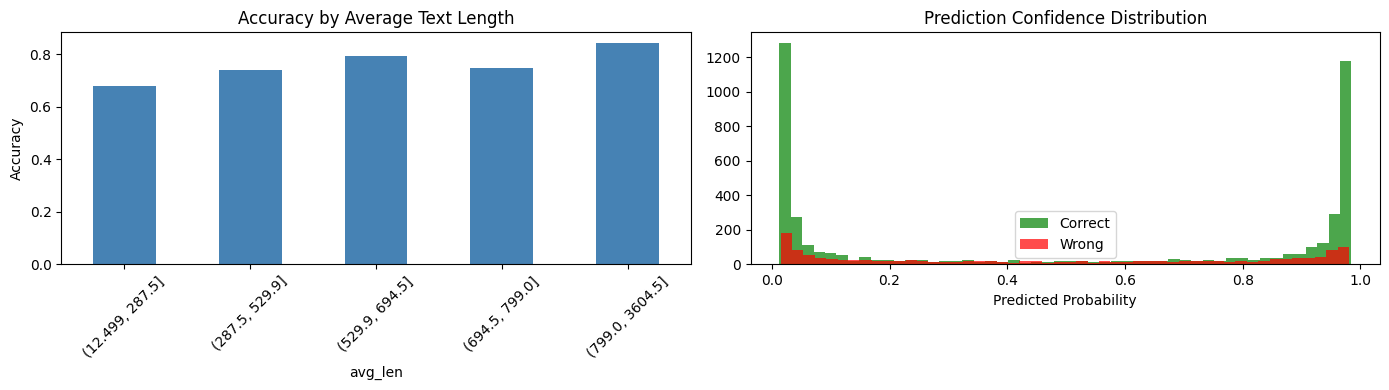

In [ ]:
# --- Accuracy by text length ---
dev_df_eval['avg_len'] = (dev_df_eval['len_1'] + dev_df_eval['len_2']) / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bins = pd.qcut(dev_df_eval['avg_len'], q=5, duplicates='drop')
acc_by_len = dev_df_eval.groupby(bins)['correct'].mean()
acc_by_len.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Accuracy by Average Text Length')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=45)

# Confidence distribution
correct_probs = dev_probs[dev_df_eval['correct'].values == 1]
wrong_probs = dev_probs[dev_df_eval['correct'].values == 0]
axes[1].hist(correct_probs, bins=50, alpha=0.7, label='Correct', color='green')
axes[1].hist(wrong_probs, bins=50, alpha=0.7, label='Wrong', color='red')
axes[1].set_title('Prediction Confidence Distribution')
axes[1].set_xlabel('Predicted Probability')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# --- Sample errors ---
print("=" * 80)
print("SAMPLE FALSE POSITIVES (predicted same author, actually different)")
print("=" * 80)
fp = errors[errors['label'] == 0].head(3)
for _, row in fp.iterrows():
    print(f"\nText 1: {row['text_1'][:150]}...")
    print(f"Text 2: {row['text_2'][:150]}...")
    print("-" * 40)

print("\n" + "=" * 80)
print("SAMPLE FALSE NEGATIVES (predicted different author, actually same)")
print("=" * 80)
fn = errors[errors['label'] == 1].head(3)
for _, row in fn.iterrows():
    print(f"\nText 1: {row['text_1'][:150]}...")
    print(f"Text 2: {row['text_2'][:150]}...")
    print("-" * 40)


SAMPLE FALSE POSITIVES (predicted same author, actually different)

Text 1: Paul Newman , Elizabeth Taylor , Burl Ives , Judith Anderson , Jack Carson , and Madeline Sherwood star in " Cat on a Hot Tin Roof , " a watered down ...
Text 2: Director John Milius also takes writing credit for this very colorful look at the most famous bank robber John Dillinger ( Warren Oates ) . This story...
----------------------------------------

Text 1: If you want a brainless 90 minutes in which you simply do not want to think then this is the kind of movie you might want to rent . Frankie Munitz , m...
Text 2: Of course , Chaplin's early career is over-flowing with famous short comedies , but The Tramp is probably one of the most well-known of the early two-...
----------------------------------------

Text 1: Film depicts life in the small Texas town of Anarene in the early 1950s . It follows three high school teenagers - - Sonny Crawford ( Timothy Bottoms ...
Text 2: This film is sometimes consign

## 12. Inference / Demo Code

Given a test CSV with `text_1` and `text_2` columns (no labels), generates predictions.


In [ ]:
def predict_from_file(input_path, output_path, model_path='best_siamese_bilstm_v2.pt',
                      threshold=0.5):
    """
    Load model, extract features, generate predictions for test data.
    """
    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
    config = checkpoint['config']
    saved_vocab = checkpoint['vocab']
    saved_scaler = checkpoint['style_scaler']

    # Rebuild model
    inference_model = SiameseBiLSTM(
        embedding_matrix=embedding_matrix,
        hidden_dim=config['hidden_dim'],
        num_layers=config['num_layers'],
        style_feat_dim=config['style_dim'],
        dropout=0.0,
    ).to(DEVICE)
    inference_model.load_state_dict(checkpoint['model_state_dict'])
    inference_model.eval()

    # Load test data
    test_df = pd.read_csv(input_path)
    test_df['text_1'] = test_df['text_1'].fillna('')
    test_df['text_2'] = test_df['text_2'].fillna('')
    print(f"Loaded {len(test_df)} test pairs")

    # Extract stylometric features
    test_style_feats, _ = compute_pair_stylometric_features(test_df)
    test_style_feats = saved_scaler.transform(test_style_feats)

    # Create dataset
    test_df['label'] = 0  # placeholder
    test_dataset = AuthorshipDataset(test_df, test_style_feats, saved_vocab,
                                      config['max_len'], config['char_max_len'],
                                      augment=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Predict
    all_preds = []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Predicting"):
            text1 = batch['text1'].to(DEVICE)
            text2 = batch['text2'].to(DEVICE)
            char1 = batch['char1'].to(DEVICE)
            char2 = batch['char2'].to(DEVICE)
            style = batch['style'].to(DEVICE)

            logits = inference_model(text1, text2, char1, char2, style)
            preds = (torch.sigmoid(logits) >= threshold).long()
            all_preds.extend(preds.cpu().numpy())

    pred_df = pd.DataFrame({'prediction': all_preds})
    pred_df.to_csv(output_path, index=False)
    print(f"Predictions saved to {output_path}")
    print(f"Threshold: {threshold}")
    print(f"Distribution: {pd.Series(all_preds).value_counts().to_dict()}")
    return pred_df

# --- Example usage ---
# predict_from_file('test.csv', 'Group_n_B.csv', threshold=best_threshold)


## 13. Save Artefacts


In [ ]:
# Save vocab and scaler separately (backup)
with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)
with open('style_scaler.pkl', 'wb') as f:
    pickle.dump(style_scaler, f)

print("Saved artefacts:")
print("  - best_siamese_bilstm_v2.pt  (model + vocab + scaler)")
print("  - vocab.pkl                   (vocabulary backup)")
print("  - style_scaler.pkl            (feature scaler backup)")
print(f"\nBest threshold: {best_threshold:.2f}")
print("\nUpload model to OneDrive if > 10MB and include link in README.")


Saved artefacts:
  - best_siamese_bilstm_v2.pt  (model + vocab + scaler)
  - vocab.pkl                   (vocabulary backup)
  - style_scaler.pkl            (feature scaler backup)

Best threshold: 0.42

Upload model to OneDrive if > 10MB and include link in README.


In [ ]:
# ============================================================
# ENSEMBLE: Train 3 models with different seeds, average predictions
# ============================================================

from copy import deepcopy

ensemble_probs = []
seeds = [42, 123, 777]

for seed_idx, s in enumerate(seeds):
    print(f"\n{'='*50}")
    print(f"Training model {seed_idx+1}/3 with seed {s}")
    print(f"{'='*50}")

    # Set seed
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

    # Fresh model
    ens_model = SiameseBiLSTM(
        embedding_matrix=embedding_matrix,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        style_feat_dim=STYLE_DIM,
        dropout=DROPOUT,
    ).to(DEVICE)
    ens_model.embedding.weight.requires_grad = False

    ens_optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, ens_model.parameters()),
        lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    ens_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(ens_optimizer, T_max=NUM_EPOCHS)
    ens_criterion = nn.BCEWithLogitsLoss()

    # Re-create loader with shuffle (different order per seed)
    ens_train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                                   num_workers=0, pin_memory=True)

    best_ens_f1 = 0
    patience_ctr = 0

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss = train_epoch(ens_model, ens_train_loader, ens_optimizer,
                                  ens_criterion, DEVICE, accum_steps=ACCUM_STEPS)
        dev_loss, dev_f1, dev_acc, _, dev_probs_ens, dev_labels_ens = evaluate(
            ens_model, dev_loader, ens_criterion, DEVICE)
        ens_scheduler.step()

        print(f"  Epoch {epoch:2d} | Train: {train_loss:.4f} | Dev F1: {dev_f1:.4f}")

        if dev_f1 > best_ens_f1:
            best_ens_f1 = dev_f1
            best_probs = dev_probs_ens.copy()
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"  Early stopping at epoch {epoch}")
                break

    print(f"  Best F1: {best_ens_f1:.4f}")
    ensemble_probs.append(best_probs)

# Average probabilities across all models
avg_probs = np.mean(ensemble_probs, axis=0)

# Threshold sweep on ensemble
print(f"\n{'='*50}")
print("ENSEMBLE RESULTS")
print(f"{'='*50}")
best_t, best_f1_ens = 0.5, 0
for t in np.arange(0.35, 0.65, 0.02):
    p = (avg_probs >= t).astype(int)
    f = f1_score(dev_labels_ens, p, average='macro')
    if f > best_f1_ens:
        best_f1_ens = f
        best_t = t

preds_final = (avg_probs >= best_t).astype(int)
final_f1 = f1_score(dev_labels_ens, preds_final, average='macro')
final_acc = accuracy_score(dev_labels_ens, preds_final)

print(f"Ensemble F1:  {final_f1:.4f}")
print(f"Ensemble Acc: {final_acc:.4f}")
print(f"Threshold:    {best_t:.2f}")
print(f"\nClassification Report:")
print(classification_report(dev_labels_ens, preds_final,
                            target_names=['Different Author (0)', 'Same Author (1)']))


Training model 1/3 with seed 42


Training:   0%|          | 0/432 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

  Epoch  1 | Train: 0.7007 | Dev F1: 0.3436


Training:   0%|          | 0/432 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

  Epoch 19 | Train: 0.3054 | Dev F1: 0.7471


Training:   0%|          | 0/432 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

  Epoch 20 | Train: 0.3019 | Dev F1: 0.7508
  Best F1: 0.7508

ENSEMBLE RESULTS
Ensemble F1:  0.7674
Ensemble Acc: 0.7674
Threshold:    0.53

Classification Report:
                      precision    recall  f1-score   support

Different Author (0)       0.75      0.79      0.77      2937
     Same Author (1)       0.79      0.75      0.77      3056

            accuracy                           0.77      5993
           macro avg       0.77      0.77      0.77      5993
        weighted avg       0.77      0.77      0.77      5993



In [ ]:
# Generate predictions CSV from dev set using best model
pred_df = pd.DataFrame({'prediction': dev_preds.astype(int)})
pred_df.to_csv('Group_n_B.csv', index=False)
print(f"Saved {len(pred_df)} predictions")
print(pred_df.head())

Saved 5993 predictions
   prediction
0           0
1           0
2           1
3           0
4           0


## Summary

**Architecture:** Siamese BiLSTM + Character CNN + Stylometric Features

**Key components:**
- GloVe 100d embeddings → Spatial dropout → BiLSTM (2 layers, 150 hidden)
- Multi-head attention pooling (4 heads)
- Character CNN (filter sizes 3,4,5,7) for punctuation/spelling patterns
- 29 handcrafted stylometric feature differences
- Classifier with LayerNorm + residual connections

**Regularisation:** dropout 0.4, spatial dropout 0.2, weight decay 5e-4, label smoothing 0.05, swap augmentation

**For your poster:** This is Category B (no transformers). Highlight the three parallel feature streams (word BiLSTM, char CNN, stylometric) and how they capture different aspects of authorship style.
